# Customer Churn Prediction ANN


In [24]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf

In [25]:
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import binary_crossentropy
from tensorflow.keras.models import Sequential
from tensorflow.keras import regularizers

In [26]:
df = pd.read_csv("datasets\Churn_Modelling.csv")
df

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


In [27]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [29]:
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [30]:
df.isnull().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [31]:
df['Gender'].nunique()

2

In [32]:
df['Geography'].nunique()

3

In [33]:
df['Surname'].nunique()

2932

In [34]:
df = df.drop(['RowNumber', 'CustomerId'], axis=1)

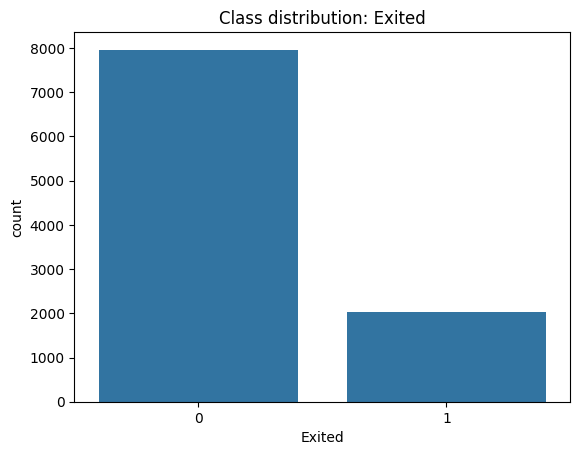

In [35]:
sns.countplot(x='Exited', data=df)
plt.title('Class distribution: Exited')
plt.show()

In [36]:
from sklearn.preprocessing import LabelEncoder

In [37]:
label_encoders = {}
for col in ["Surname", "Geography", "Gender"]:
  label_encoders[col] = LabelEncoder()
  df[col] = label_encoders[col].fit_transform(df[col])

df.head()

,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1115,619,0,0,42,2,0.00,1,1,1,101348.88,1
1,1177,608,2,0,41,1,83807.86,1,0,1,112542.58,0
2,2040,502,0,0,42,8,159660.80,3,1,0,113931.57,1
3,289,699,0,0,39,1,0.00,2,0,0,93826.63,0
4,1822,850,2,0,43,2,125510.82,1,1,1,79084.10,0


In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Surname          10000 non-null  int64  
 1   CreditScore      10000 non-null  int64  
 2   Geography        10000 non-null  int64  
 3   Gender           10000 non-null  int64  
 4   Age              10000 non-null  int64  
 5   Tenure           10000 non-null  int64  
 6   Balance          10000 non-null  float64
 7   NumOfProducts    10000 non-null  int64  
 8   HasCrCard        10000 non-null  int64  
 9   IsActiveMember   10000 non-null  int64  
 10  EstimatedSalary  10000 non-null  float64
 11  Exited           10000 non-null  int64  
dtypes: float64(2), int64(10)
memory usage: 937.6 KB


In [39]:
from sklearn.model_selection import train_test_split
X = df.drop("Exited", axis=1)
y = df["Exited"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=3)

In [40]:
model = Sequential([
    Dense(16, activation='relu', input_shape=(X_train.shape[1],)),
    BatchNormalization(),
    Dropout(0.3),
    Dense(32, activation='relu', kernel_regularizer=regularizers.l2(0.2)),
    BatchNormalization(),
    Dropout(0.3),
    Dense(64, activation='relu', kernel_regularizer=regularizers.l2(0.2)),
    BatchNormalization(),
    Dropout(0.3),
    Dense(32, activation='relu', kernel_regularizer=regularizers.l2(0.2)),
    BatchNormalization(),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

d:\B.Tech\ProjeX\MachineLearning\Deeplearning\.venv\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [41]:
model.compile(optimizer=Adam(), loss=binary_crossentropy, metrics=['accuracy'])

In [42]:
history = model.fit(X_train, y_train, epochs=50, batch_size=32, validation_data=(X_test, y_test))

Epoch 1/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.6469 - loss: 8.2475 - val_accuracy: 0.8025 - val_loss: 2.0213
Epoch 2/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7629 - loss: 1.1666 - val_accuracy: 0.8025 - val_loss: 0.6908
Epoch 3/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7824 - loss: 0.6448 - val_accuracy: 0.8025 - val_loss: 0.5692
Epoch 4/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7874 - loss: 0.5880 - val_accuracy: 0.8025 - val_loss: 0.5416
Epoch 5/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7914 - loss: 0.5525 - val_accuracy: 0.8025 - val_loss: 0.5200
Epoch 6/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7941 - loss: 0.5263 - val_accuracy: 0.8025 - val_loss: 0.5070
Epoch 7/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7946 - loss: 0.5177 - val_accuracy: 0.8025 - val_loss: 0.5008
Epoch 8/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7947 - loss: 0.5104 - val_accuracy: 0.

In [50]:
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix, accuracy_score
scores = model.evaluate(X_test, y_test, verbose=0)
print(f'Test loss: {scores[0]:.4f}')
print(f'Test accuracy: {scores[1]:.4f}')

y_pred_prob = model.predict(X_test).ravel()
y_pred = (y_pred_prob >= 0.5).astype(int)
print(f'Test AUC: {roc_auc_score(y_test, y_pred_prob):.4f}')
print(f'Test accuracy (sklearn): {accuracy_score(y_test, y_pred):.4f}')
print('Classification report:')
print(classification_report(y_test, y_pred))
print('Confusion matrix:')
print(confusion_matrix(y_test, y_pred))

Test loss: 0.4939
Test accuracy: 0.8025
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Test AUC: 0.5783
Test accuracy (sklearn): 0.8025
Classification report:
              precision    recall  f1-score   support

           0       0.80      1.00      0.89      1605
           1       0.00      0.00      0.00       395

    accuracy                           0.80      2000
   macro avg       0.40      0.50      0.45      2000
weighted avg       0.64      0.80      0.71      2000

Confusion matrix:
[[1605    0]
 [ 395    0]]


d:\B.Tech\ProjeX\MachineLearning\Deeplearning\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\B.Tech\ProjeX\MachineLearning\Deeplearning\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\B.Tech\ProjeX\MachineLearning\Deeplearning\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mod

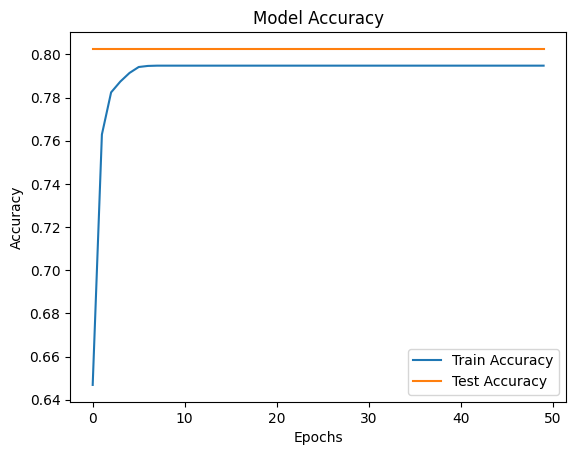

In [43]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Test Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

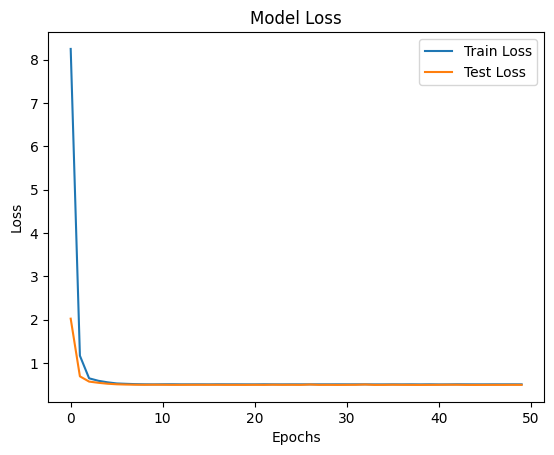

In [44]:
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Test Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [45]:
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

smote = SMOTE(random_state=3)
X_res, y_res = smote.fit_resample(X_train_scaled, y_train)
print('Original train class counts:', np.bincount(y_train))
print('Resampled train class counts:', np.bincount(y_res))

Original train class counts: [6358 1642]
Resampled train class counts: [6358 6358]


In [46]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, BatchNormalization, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import regularizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix, accuracy_score

model2 = Sequential([
    Dense(128, activation='relu', input_shape=(X_res.shape[1],), kernel_regularizer=regularizers.l2(1e-4)),
    BatchNormalization(),
    Dropout(0.3),
    Dense(64, activation='relu', kernel_regularizer=regularizers.l2(1e-4)),
    BatchNormalization(),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

model2.compile(optimizer=Adam(learning_rate=1e-3), loss='binary_crossentropy', metrics=['AUC','accuracy'])

es = EarlyStopping(monitor='val_auc', mode='max', patience=12, restore_best_weights=True)
rlr = ReduceLROnPlateau(monitor='val_auc', mode='max', factor=0.5, patience=6, min_lr=1e-6)

history2 = model2.fit(X_res, y_res, validation_data=(X_test_scaled, y_test), epochs=200, batch_size=64, callbacks=[es, rlr])

scores = model2.evaluate(X_test_scaled, y_test, verbose=0)
print(f'Test loss: {scores[0]:.4f}')
print(f'Test AUC: {scores[1]:.4f}')
print(f'Test accuracy: {scores[2]:.4f}')

y_pred_prob = model2.predict(X_test_scaled).ravel()
y_pred = (y_pred_prob >= 0.5).astype(int)
print('AUC:', roc_auc_score(y_test, y_pred_prob))
print('Accuracy:', accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

Epoch 1/200


d:\B.Tech\ProjeX\MachineLearning\Deeplearning\.venv\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


199/199 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - AUC: 0.7740 - accuracy: 0.7064 - loss: 0.5983 - val_AUC: 0.8201 - val_accuracy: 0.6735 - val_loss: 0.6070 - learning_rate: 0.0010
Epoch 2/200
 43/199 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - AUC: 0.8153 - accuracy: 0.7306 - loss: 0.5427

d:\B.Tech\ProjeX\MachineLearning\Deeplearning\.venv\Lib\site-packages\keras\src\callbacks\early_stopping.py:99: UserWarning: Early stopping conditioned on metric `val_auc` which is not available. Available metrics are: AUC,accuracy,loss,val_AUC,val_accuracy,val_loss
  current = self.get_monitor_value(logs)
d:\B.Tech\ProjeX\MachineLearning\Deeplearning\.venv\Lib\site-packages\keras\src\callbacks\callback_list.py:171: UserWarning: Learning rate reduction is conditioned on metric `val_auc` which is not available. Available metrics are: AUC,accuracy,loss,val_AUC,val_accuracy,val_loss,learning_rate.
  callback.on_epoch_end(epoch, logs)


199/199 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - AUC: 0.8349 - accuracy: 0.7525 - loss: 0.5126 - val_AUC: 0.8315 - val_accuracy: 0.7575 - val_loss: 0.5010 - learning_rate: 0.0010
Epoch 3/200
199/199 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - AUC: 0.8514 - accuracy: 0.7656 - loss: 0.4877 - val_AUC: 0.8340 - val_accuracy: 0.7570 - val_loss: 0.4957 - learning_rate: 0.0010
Epoch 4/200
199/199 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - AUC: 0.8601 - accuracy: 0.7737 - loss: 0.4752 - val_AUC: 0.8381 - val_accuracy: 0.7720 - val_loss: 0.4686 - learning_rate: 0.0010
Epoch 5/200
199/199 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - AUC: 0.8684 - accuracy: 0.7829 - loss: 0.4636 - val_AUC: 0.8383 - val_accuracy: 0.7755 - val_loss: 0.4658 - learning_rate: 0.0010
Epoch 6/200
199/199 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - AUC: 0.8728 - accuracy: 0.7902 - loss: 0.4561 - val_AUC: 0.8412 - val_accuracy: 0.7680 - val_loss: 0.4701 - learning_rate: 0.0010
Epoch 7/200
199/199 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - AUC: 0.8777 - accuracy: 0.7939 -